In [8]:
import os
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

# Safe connection — password from environment variable
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password=os.environ.get('MYSQL_PASSWORD')
)

print("✓ Connected to MySQL securely")
print(f"MySQL version: {conn.server_info}")

✓ Connected to MySQL securely
MySQL version: 8.0.46


In [9]:
import os
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Secure connection
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password=os.environ.get('MYSQL_PASSWORD')
)
cursor = conn.cursor()
cursor.execute("USE energy_analytics")
print("✓ Connected to energy_analytics database")

✓ Connected to energy_analytics database


In [10]:
# Check what's in the database
cursor.execute("SHOW TABLES")
tables = cursor.fetchall()
print("Tables in energy_analytics:")
for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table[0]}")
    count = cursor.fetchone()[0]
    print(f"  {table[0]}: {count} records")

Tables in energy_analytics:
  city_summary: 18 records
  countries: 16 records
  solar_data: 2574 records


In [11]:
# Q1 — Top 5 cities by solar potential
print("=" * 50)
print("Q1: Top 5 Cities by Annual Average GHI")
print("=" * 50)
cursor.execute("""
    SELECT city, country_name, climate_zone,
           ROUND(mean_ghi, 3) AS mean_ghi
    FROM city_summary
    ORDER BY mean_ghi DESC
    LIMIT 5
""")
for row in cursor.fetchall():
    print(f"  {row[0]:<15} {row[1]:<15} {row[2]:<15} {row[3]} kWh/m²/day")

# Q2 — Harmattan vs Non-Harmattan
print("\n" + "=" * 50)
print("Q2: Harmattan vs Non-Harmattan GHI by Zone")
print("=" * 50)
cursor.execute("""
    SELECT climate_zone, season,
           ROUND(AVG(ghi), 3) AS avg_ghi,
           COUNT(*) AS records
    FROM solar_data
    GROUP BY climate_zone, season
    ORDER BY climate_zone, season
""")
for row in cursor.fetchall():
    print(f"  {row[0]:<15} {row[1]:<15} {row[2]} kWh/m²/day ({row[3]} records)")

# Q3 — High solar + low access
print("\n" + "=" * 50)
print("Q3: High Solar Potential + Low Electricity Access")
print("=" * 50)
cursor.execute("""
    SELECT c.display_name, c.electricity_access_2023,
           ROUND(AVG(s.mean_ghi), 3) AS avg_ghi
    FROM countries c
    JOIN city_summary s ON c.display_name = s.country_name
    WHERE c.electricity_access_2023 < 55
    GROUP BY c.display_name, c.electricity_access_2023
    ORDER BY avg_ghi DESC
""")
for row in cursor.fetchall():
    print(f"  {row[0]:<15} Access: {row[1]}%  GHI: {row[2]} kWh/m²/day")

# Q4 — Monthly GHI for Lagos
print("\n" + "=" * 50)
print("Q4: Monthly Average GHI for Lagos")
print("=" * 50)
cursor.execute("""
    SELECT month, ROUND(AVG(ghi), 3) AS avg_ghi
    FROM solar_data
    WHERE city = 'Lagos'
    GROUP BY month
    ORDER BY month
""")
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
for row in cursor.fetchall():
    print(f"  {months[row[0]-1]}: {row[1]} kWh/m²/day")

# Q5 — Best solar year per zone
print("\n" + "=" * 50)
print("Q5: Best Solar Year per Climate Zone")
print("=" * 50)
cursor.execute("""
    SELECT climate_zone, year,
           ROUND(AVG(ghi), 3) AS avg_ghi
    FROM solar_data
    GROUP BY climate_zone, year
    ORDER BY climate_zone, avg_ghi DESC
""")
results = cursor.fetchall()
best_years = {}
for row in results:
    zone = row[0]
    if zone not in best_years:
        best_years[zone] = (row[1], row[2])
for zone, (year, ghi) in sorted(best_years.items(),
                                  key=lambda x: x[1][1],
                                  reverse=True):
    print(f"  {zone:<15} Best year: {year}  GHI: {ghi} kWh/m²/day")

Q1: Top 5 Cities by Annual Average GHI
  Nouakchott      Mauritania      Desert/Arid     6.291 kWh/m²/day
  Niamey          Niger           Sahel           6.052 kWh/m²/day
  Kano            Nigeria         Sahel           5.973 kWh/m²/day
  Praia           Cape Verde      Desert/Arid     5.889 kWh/m²/day
  Ouagadougou     Burkina Faso    Sahel           5.822 kWh/m²/day

Q2: Harmattan vs Non-Harmattan GHI by Zone
  Coastal Humid   Harmattan       5.213 kWh/m²/day (531 records)
  Coastal Humid   Non-Harmattan   4.639 kWh/m²/day (756 records)
  Desert/Arid     Harmattan       5.468 kWh/m²/day (118 records)
  Desert/Arid     Non-Harmattan   6.527 kWh/m²/day (168 records)
  Sahel           Harmattan       5.801 kWh/m²/day (354 records)
  Sahel           Non-Harmattan   5.919 kWh/m²/day (504 records)
  Savanna         Harmattan       5.722 kWh/m²/day (59 records)
  Savanna         Non-Harmattan   4.951 kWh/m²/day (84 records)

Q3: High Solar Potential + Low Electricity Access
  Mauritania 

C:\Users\User\AppData\Local\Temp\ipykernel_3588\234896137.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sql_df = pd.read_sql("""


✓ 18 cities retrieved from MySQL


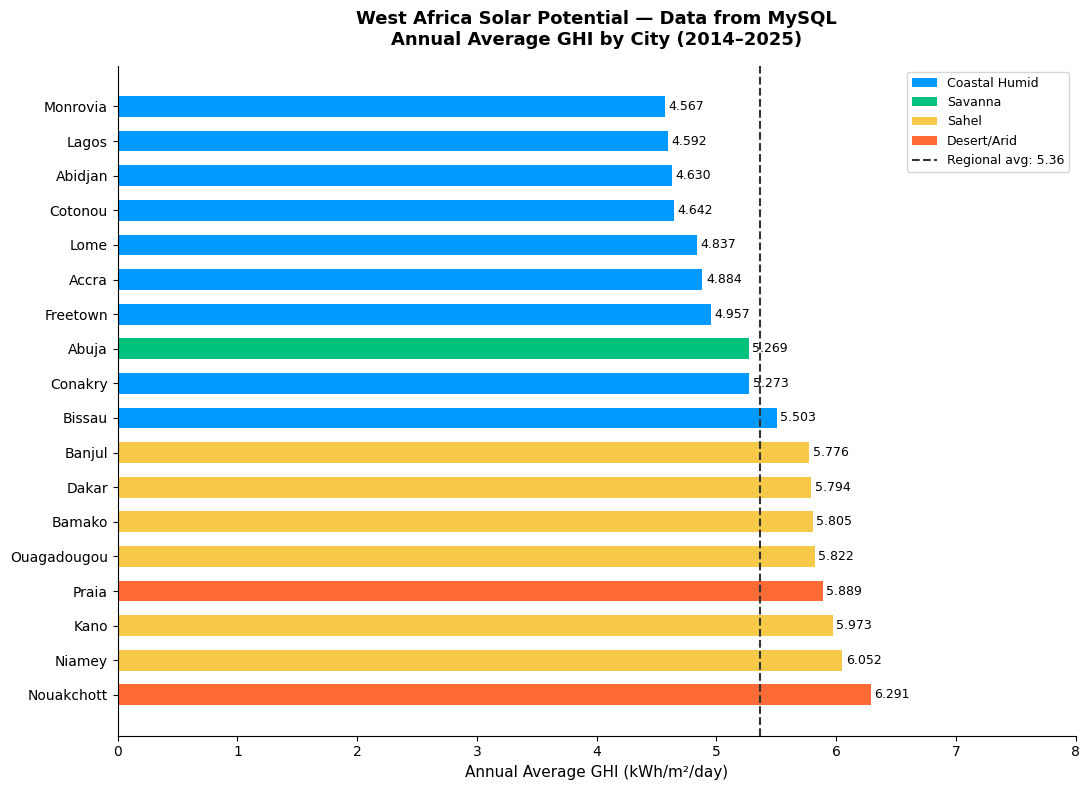

✓ Full pipeline: MySQL → Python → Chart


In [12]:
# Pull city summary from SQL into Pandas
sql_df = pd.read_sql("""
    SELECT city, country_name, climate_zone,
           ROUND(mean_ghi, 3) AS mean_ghi
    FROM city_summary
    ORDER BY mean_ghi DESC
""", conn)

print(f"✓ {len(sql_df)} cities retrieved from MySQL")

# Build chart
zone_colors = {
    'Coastal Humid': '#0099ff',
    'Savanna':       '#00c27c',
    'Sahel':         '#f7c948',
    'Desert/Arid':   '#ff6b35'
}

colors = [zone_colors[z] for z in sql_df['climate_zone']]
avg = sql_df['mean_ghi'].mean()

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(sql_df['city'], sql_df['mean_ghi'],
               color=colors, edgecolor='none', height=0.6)

for bar, val in zip(bars, sql_df['mean_ghi']):
    ax.text(val + 0.03, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.axvline(x=avg, color='#333333', linestyle='--',
           linewidth=1.5, label=f'Regional avg: {avg:.2f} kWh/m²/day')

ax.set_title('West Africa Solar Potential — Data from MySQL\n'
             'Annual Average GHI by City (2014–2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Annual Average GHI (kWh/m²/day)', fontsize=11)
ax.set_xlim(0, 8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=z)
                   for z, c in zone_colors.items()]
legend_elements.append(plt.Line2D([0], [0], color='#333333',
                                   linestyle='--',
                                   label=f'Regional avg: {avg:.2f}'))
ax.legend(handles=legend_elements, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/sql_pipeline_chart.png', dpi=150)
plt.show()
print("✓ Full pipeline: MySQL → Python → Chart")

## MySQL Energy Database: Key findingss

### Why a database instead of CSV Files
CSV files work fine for one project. But portfolio grows to cover solar data, electricity access, grid performance, and carbon emissions across Africa, I will need a structured way to store, query, and combine datasets. This is where relational database solves this. The tables are linked by shared keys, queries are fast even on large datasets, and multiple projects can draw from the same data source without duplicating files.

### What the 5 Queries Revealed
The SQL queries didn't just retrieve data, they answered real energy questions.Niger (20.1% access, 6.052 kWh/m²/day) and Burkina Faso (21.7% access, 5.822 kWh/m²/day) emerged as the most compelling solar investment 
cases in West Africa. 

### The Full Pipeline
The final chart demonstrates a professional data workflow: 
raw NASA satellite data → cleaned and structured in Python → stored in a MySQL relational database → queried with SQL → visualised in Matplotlib.


In [13]:
cursor.close()
conn.close()
print("✓ Database connection closed cleanly")

✓ Database connection closed cleanly
